# Tema : Modelos de suavización exponencial
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

In [185]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing # Simple Exponential Smoothing
from statsmodels.tsa.holtwinters import Holt # Holt's Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holt Winter's Exponential Smoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel # ETS models.
from statsmodels.tsa.deterministic import DeterministicProcess # Regresión Armónica Dinámica
from statsmodels.tsa.api import SARIMAX # SOLO para Regresión Armónica Dinámica


import warnings
warnings.filterwarnings('ignore')


## Modelo SES

$$
\begin{align*}
\text{Ecuación de pronóstico} && \hat{y}_{t+h|t} = \ell_{t} \\
\text{Ecuación de suavizado} && \ell_{t} = \alpha y_{t} + (1 - \alpha)\ell_{t-1}
\end{align*}
$$

- Trend (None): El modelo asume que el PIB no tiene una tendencia alcista o bajista constante en el tiempo. Por eso, el pronóstico futuro será una línea recta horizontal.
- Seasonal (None): No se detectaron ni aplicaron patrones que se repitan (como ciclos anuales).

### Ejercicio 1. Pronostico del crecimiento PIB de Colombia.

Usando los datos del Banco Mundial, estimar la Suavizamiento Exponencial Simple como función de prónostico del crecimento anual del PIB de Colombia. 1960-2024. Finalmente, realice el pronóstico del PIB de Colombia para los próximos 5 años.



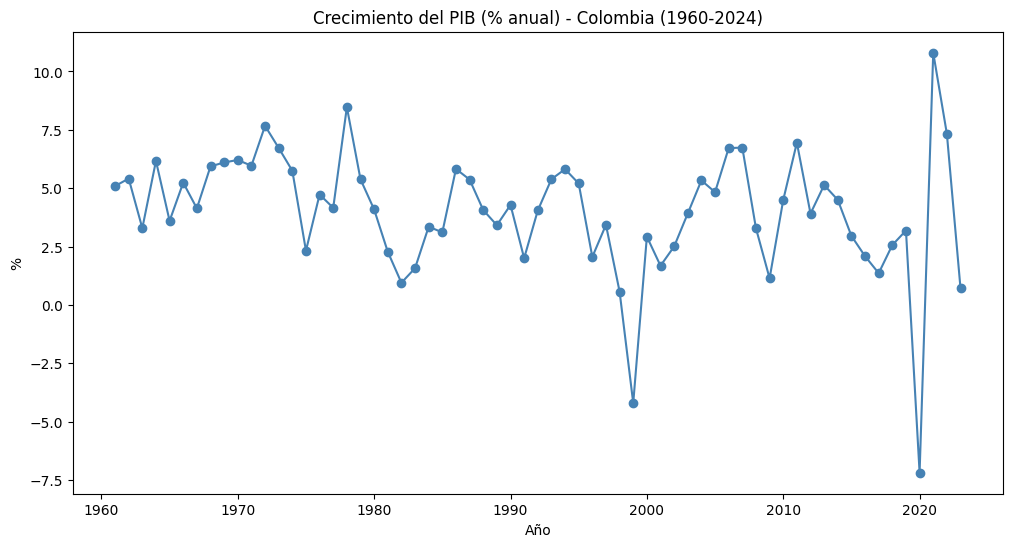

In [113]:
# Descargar los datos del Banco Mundial
data = wb.data.DataFrame(series='NY.GDP.MKTP.KD.ZG', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
pib_col = data['pib'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, data['pib'], marker='o', color='steelblue')
ax.set_title('Crecimiento del PIB (% anual) - Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('%')
plt.show()


In [114]:
modelo_ses = SimpleExpSmoothing(pib_col, initialization_method="estimated").fit()
print(modelo_ses.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                    pib   No. Observations:                   63
Model:             SimpleExpSmoothing   SSE                            451.337
Optimized:                       True   AIC                            128.052
Trend:                           None   BIC                            132.338
Seasonal:                        None   AICC                           128.742
Seasonal Periods:                None   Date:                 Mon, 13 Apr 2026
Box-Cox:                        False   Time:                         16:43:30
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0517261                alpha                 True
initial_level              4.5991175                

$$
\begin{align*}
\text{Ecuación de pronóstico} && \hat{y}_{t+h|t} = \ell_{t} \\
\text{Ecuación de suavizado} && \ell_{t} = 0.0517261 y_{t} + (1 - 0.0517261)\ell_{t-1} \\
\text{Valor inicial} && \ell_{0} = 4.5991175
\end{align*}
$$

**Interpretación**

- El modelo le asigna solo un 5.17% de peso al dato más reciente (el último año observado) y un 94.83% de peso a la historia previa (el nivel suavizado anterior).
- El valor $\alpha$ al ser un valor muy cercano a 0, el modelo es muy conservador e ignora las fluctuaciones de corto plazo y prefiere mantener un promedio estable de largo plazo ($\ell_{0}$).


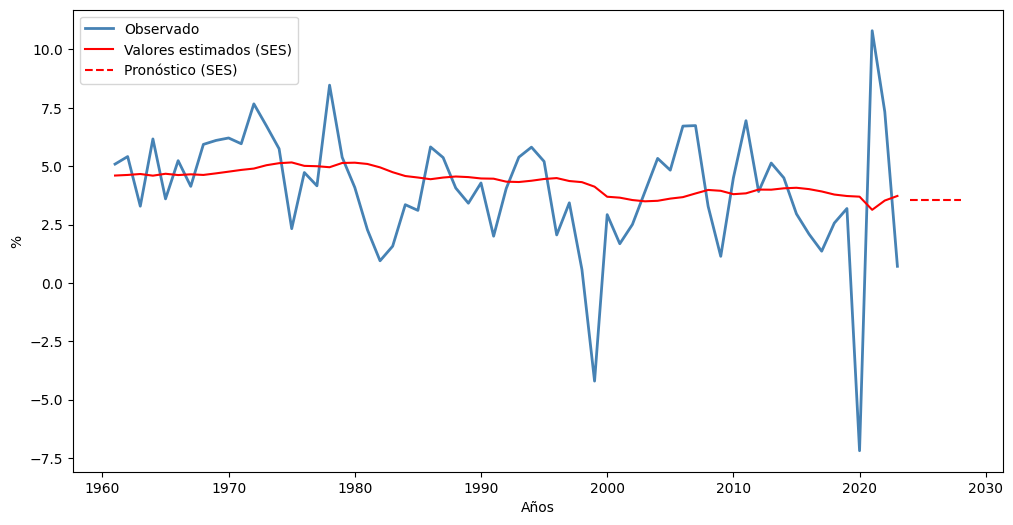

In [115]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_dato  = pib_col.index[-1]
anio_pronostico = range(ultimo_dato + 1, ultimo_dato + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_ses = modelo_ses.forecast(steps=t_pronostico)
pronostico_ses.index = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_col.index, pib_col, label="Observado", color='steelblue', linewidth=2)
ax.plot(pib_col.index, modelo_ses.fittedvalues, label="Valores estimados (SES)", color='red')
ax.plot(pronostico_ses.index, pronostico_ses, label="Pronóstico (SES)", color='red', linestyle='--')
ax.set_xlabel('Años')
ax.set_ylabel('%')
ax.legend()
plt.show()

## Modelo Holt con tendencia constante y amortiguada

**Holt tendencia**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} = \ell_{t} + hb_{t} \\
  \text{Ecuación nivel}   && \ell_{t} = \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t}    = \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)b_{t-1}
\end{align*}
$$

**Holt tendencia amortiguada**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + (\phi+\phi^2 + \dots + \phi^{h})b_{t} \\
  \text{Ecuación nivel}   && \ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + \phi b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)\phi b_{t-1}
\end{align*}
$$

### Ejercicio 2. Pronostico del crecimiento PIB de Colombia considerando tendencia

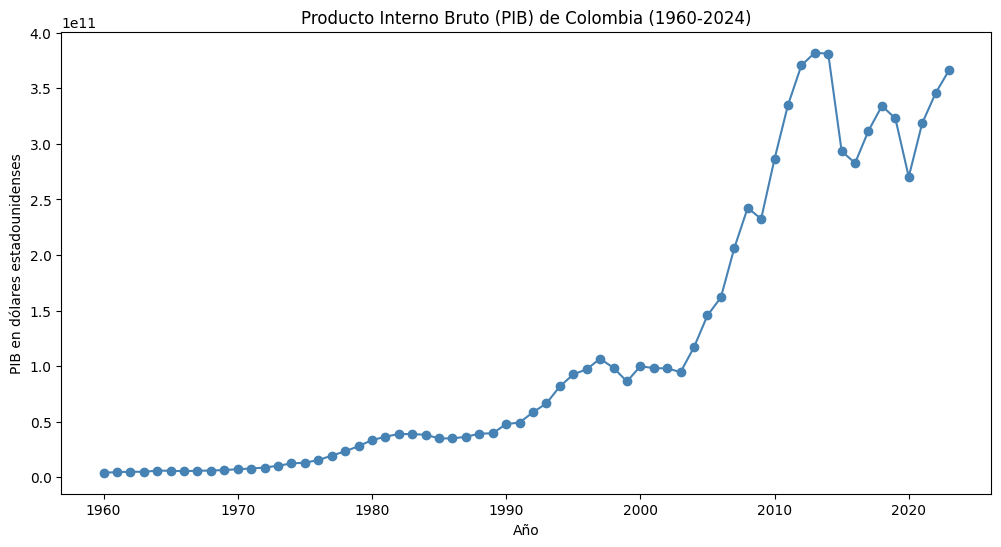

In [116]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
data["pib"] = data["pib"]
pib_col = data['pib']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, pib_col, marker='o', color='steelblue')
ax.set_title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB en dólares estadounidenses')
plt.show()


In [117]:
# Modelo Holt
modelo_holt = Holt(pib_col, initialization_method="estimated").fit()
# Modelo Holt tendencia amortiguada
modelo_holt_damped_trend = Holt(pib_col, damped_trend = True, initialization_method="estimated").fit()


In [118]:
# Imprimir modelos
print("Modelo de Holt con tendencia\n")
print(modelo_holt.summary())

Modelo de Holt con tendencia

                                   Holt Model Results                                  
Dep. Variable:                    pib   No. Observations:                            64
Model:                           Holt   SSE                 26375440606726337855488.000
Optimized:                       True   AIC                                    3045.942
Trend:                       Additive   BIC                                    3054.577
Seasonal:                        None   AICC                                   3047.415
Seasonal Periods:                None   Date:                          Mon, 13 Apr 2026
Box-Cox:                        False   Time:                                  16:43:32
Box-Cox Coeff.:                  None                                                  
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level     

**Interpretación**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} = \ell_{t} + hb_{t} \\
  \text{Ecuación nivel}   && \ell_{t} = 1.0000000 y_{t} + (1 - 1.0000000)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t}    = 0^*(\ell_{t} - \ell_{t-1}) + (1 -0^*)b_{t-1} \\
  \text{Valor inicial} && \ell_{0} = 3.6556e+09 && b_{0} = 5.6533e+09
\end{align*}
$$

- Es modelo estima $\alpha$ con valor máximo posible indicando que le da un peso del 100% a la observación más reciente y olvida por completo el nivel calculado anteriormente. A su vez, $b = 0$ con el valor mínimo posible indica que modelo no actualiza la pendiente con los datos nuevos.
- De forma conjunta el modelo se comporta como una caminata aleatora. Solo depende del valor anterior y los valores iniciales tanto de la serie como de la tendencia se mantienen están presentes en todo momento.


In [119]:
# Imprimir modelos
print("Modelo de Holt con tendencia amortiguada\n")
print(modelo_holt_damped_trend.summary())

Modelo de Holt con tendencia amortiguada

                                   Holt Model Results                                  
Dep. Variable:                    pib   No. Observations:                            64
Model:                           Holt   SSE                 26987129298023429963776.000
Optimized:                       True   AIC                                    3049.409
Trend:                       Additive   BIC                                    3060.203
Seasonal:                        None   AICC                                   3051.409
Seasonal Periods:                None   Date:                          Mon, 13 Apr 2026
Box-Cox:                        False   Time:                                  16:43:32
Box-Cox Coeff.:                  None                                                  
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothin

**Interpretación**

$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + (0.9950000 + 0.9950000^2 + \dots + 0.9950000^{h})b_{t} \\
  \text{Ecuación nivel}   && \ell_{t} &= 1.0000000 y_{t} + (1 - 1.0000000)(\ell_{t-1} + 0.9950000 b_{t-1})\\
  \text{Ecuación tendencia}   && b_{t} &= 0.0408419^*(\ell_{t} - \ell_{t-1}) + (1 -0.0408419^*)0.9950000 b_{t-1} \\
  \text{Valor inicial} && \ell_{0} = 4.0678e+09 && b_{0} = 1.0495e+09
\end{align*}
$$ 

- Similar a los resultados del modelo anterior. Sin embargo tenemos al nuevo parámetro $\phi = 0.9950000$ indicando que la tendencia se irá amortiguando o debilitando lentamente con el tiempo. Esto genera pronósticos más conservadores



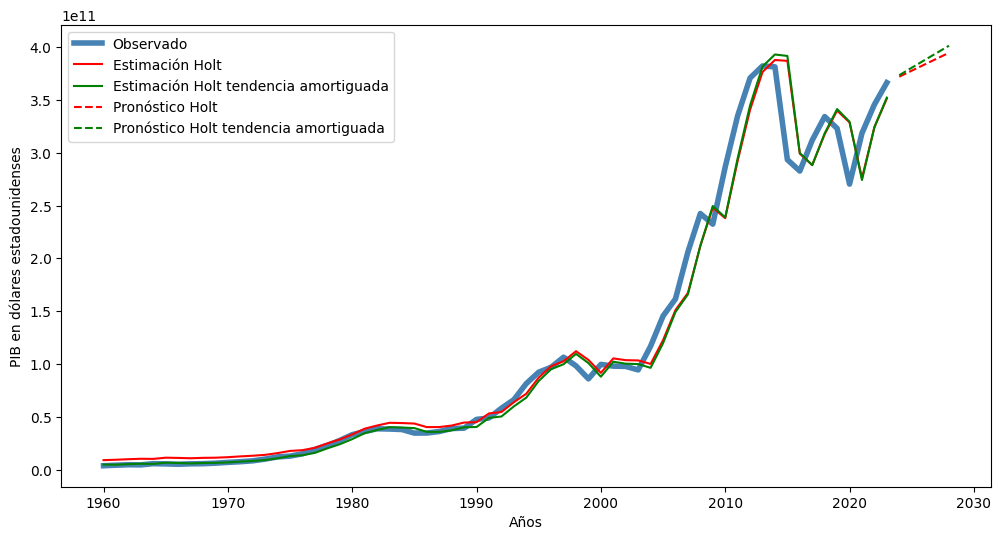

In [120]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_dato  = pib_col.index[-1]
anio_pronostico = range(ultimo_dato + 1, ultimo_dato + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_holt = modelo_holt.forecast(steps=t_pronostico)
pronostico_holt.index = anio_pronostico
pronostico_holt_damped_trend = modelo_holt_damped_trend.forecast(steps=t_pronostico)
pronostico_holt_damped_trend.index = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_col.index, pib_col, label="Observado", color='steelblue', linewidth=4)
ax.plot(pib_col.index, modelo_holt.fittedvalues, label="Estimación Holt", color='red')
ax.plot(pib_col.index, modelo_holt_damped_trend.fittedvalues, label="Estimación Holt tendencia amortiguada", color='green')

ax.plot(pronostico_holt.index, pronostico_holt, label="Pronóstico Holt", color='red', linestyle='--')
ax.plot(pronostico_holt_damped_trend.index, pronostico_holt_damped_trend, label="Pronóstico Holt tendencia amortiguada", color='green', linestyle='--')

ax.set_xlabel('Años')
ax.set_ylabel('PIB en dólares estadounidenses')
ax.legend()
plt.show()

## Holt-Winters estacionalidad

**Método aditivo**
$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} + s_{t+h-m(k+1)} \\
  \text{Ecuación nivel}&& \ell_{t} &= \alpha(y_{t} - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}&& b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}\\
  \text{Ecuación estacional}&& s_{t} &= \gamma (y_{t}-\ell_{t-1}-b_{t-1}) + (1-\gamma)s_{t-m},
\end{align*}
$$

**Método multiplicativo**
$$
\begin{align*}
  \text{Ecuación de pronóstico}&& \hat{y}_{t+h|t} &= (\ell_{t} + hb_{t})s_{t+h-m(k+1)} \\
  \text{Ecuación nivel}&& \ell_{t} &= \alpha \frac{y_{t}}{s_{t-m}} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Ecuación tendencia}&& b_{t} &= \beta^*(\ell_{t}-\ell_{t-1}) + (1 - \beta^*)b_{t-1}                \\
  \text{Ecuación estacional}&& s_{t} &= \gamma \frac{y_{t}}{(\ell_{t-1} + b_{t-1})} + (1 - \gamma)s_{t-m}.
\end{align*}
$$


### Ejemplo 3. Empleo mensual en el sector de ocio y hostelería en EE. UU

Describiremos la modelización ETS estacional utilizando datos mensuales de empleo en Estados Unidos para los trabajos de ocio y hospitalidad desde enero de 2001 hasta septiembre de 2019.

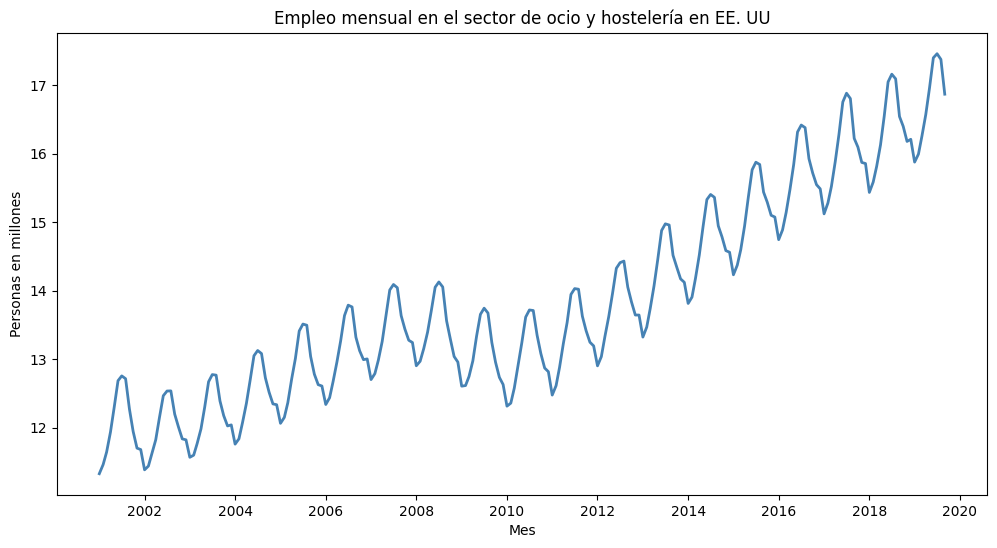

In [121]:
# leer y ajustar datos
github_data = "https://raw.githubusercontent.com/fersalme/series-tiempo-econometria/refs/heads/main/data/us_employment.csv"
datos = pd.read_csv(github_data, parse_dates=["ds"])
datos = datos.loc[(datos["ds"] >= "2001-01-01") & (datos["unique_id"] == "Leisure and Hospitality")].reset_index(drop=True)
datos["y"] = datos["y"] / 1e3
datos = datos.set_index('ds')
datos.index = pd.DatetimeIndex(datos.index).to_period('M').to_timestamp()
serie_us_employment = datos.y

# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_us_employment.index, serie_us_employment, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Personas en millones')
plt.title('Empleo mensual en el sector de ocio y hostelería en EE. UU')
plt.show()

In [122]:
# modelos
modelo_holt_winter_aditivo = ExponentialSmoothing(serie_us_employment,
                                trend="add", seasonal="add", 
                                initialization_method="estimated").fit()
modelo_holt_winter_aditivo_damped = ExponentialSmoothing(serie_us_employment,
                                trend="add", seasonal="add", damped_trend=True, 
                                initialization_method="estimated").fit()

modelo_holt_winter_mult = ExponentialSmoothing(serie_us_employment,
                                trend="add", seasonal="mul", 
                                initialization_method="estimated").fit()
modelo_holt_winter_mult_damped = ExponentialSmoothing(serie_us_employment,
                                trend="add", seasonal="mul", damped_trend=True, 
                                initialization_method="estimated").fit()

# guardar modelos
modelos_holt_winter = {"Holt-Winters" : modelo_holt_winter_aditivo, "Holt-Winters tendencia amortiguada" : modelo_holt_winter_aditivo_damped, 
                       "Holt-Winters multiplicativo" : modelo_holt_winter_mult, "Holt-Winters multiplicativo tendencia amortiguada" : modelo_holt_winter_mult_damped}


In [123]:
# menor AIC
modelos_holt_winter_aic = pd.DataFrame({
    "Modelos" : list(modelos_holt_winter),
    "AIC"  : [m.aic for m in modelos_holt_winter.values()] 
}).sort_values("AIC")

# Mejor modelo
modelos_holt_winter_aic

,Modelos,AIC
3,Holt-Winters multiplicativo tendencia amortiguada,-1470.405771
2,Holt-Winters multiplicativo,-1469.286044
0,Holt-Winters,-1408.085894
1,Holt-Winters tendencia amortiguada,-1407.631657


In [124]:
# Imprimir modelo
print("Modelo método de Holt-Winters multiplicativo con tendencia amortiguada\n")
print(modelos_holt_winter[modelos_holt_winter_aic.Modelos.iloc[0]].summary())

Modelo método de Holt-Winters multiplicativo con tendencia amortiguada

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                  225
Model:             ExponentialSmoothing   SSE                              0.281
Optimized:                         True   AIC                          -1470.406
Trend:                         Additive   BIC                          -1412.332
Seasonal:                Multiplicative   AICC                         -1466.698
Seasonal Periods:                    12   Date:                 Mon, 13 Apr 2026
Box-Cox:                          False   Time:                         16:43:38
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               1.000

$$
\begin{align*}
  \hat{y}_{t+h|t} &= \left[\ell_{t} + (0.9654+0.9654^2 + \dots + 0.9654^{h})b_{t}\right]s_{t+h-12(k+1)} \\
  \ell_{t} &= 1.0(y_{t} / s_{t-12}) + (1 - 1.0)(\ell_{t-1} + 0.9654 b_{t-1})\\
  b_{t} &= 0.1775(\ell_{t} - \ell_{t-1}) + (1 - 0.1775)0.9654 b_{t-1}             \\
  s_{t} &= 1.4857e-08 \frac{y_{t}}{(\ell_{t-1} + 0.9654 b_{t-1})} + (1 - 1.4857e-08)s_{t-12}.
\end{align*}
$$

**Interpretación**

- Al ser Multiplicativo, el modelo asume que la estacionalidad varía en proporción al nivel de la serie, es decir, los "picos" se hacen más grandes si el valor de la serie aumenta.
- Parámetro de suavizamiento de nivel ($\alpha : 1.0000000$) : El actual de la serie depende del valor anterior
- Parámetro de suavizamiento de tendencia ($\beta: 0.1774632$) : El modelo cambia su estimación de la pendiente de forma pausada.
- Parámetro de suavizamiento de estacional ($\gamma \sim 0$) : El patrón estacional es estático por lo que el comportamiento se repite exactamente igual año tras año y no necesita actualizarse con la información nueva. 
- Tendencia amortiguada ($\phi : 0.9653$): Evita que la serie cresca hasta el infinito si no que crece pero cada vez menos (~3% menos)
- Componente estacional multiplicativo (s.0 a s.11): Indica que en momentos de temporada alta como en el mes de mayo (initial_seasons.5) la serie es un 2,7% más alta que el comportamiento promedio y en momentos bajos como enero (initial_seasons.0) la serie está un 6.3% por debajo.

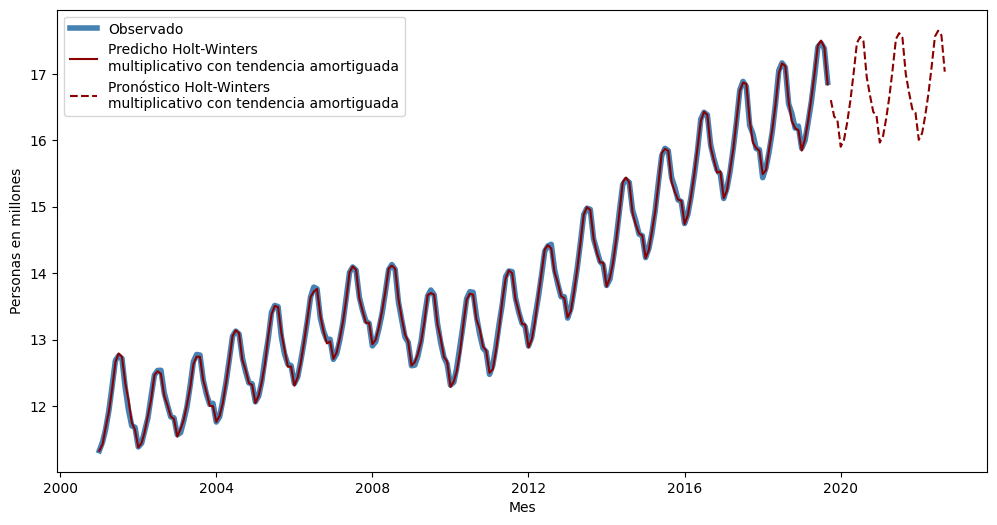

In [125]:
# Pronostico de los proximos 3 años = 12 meses * 3 años  = 36
t_pronostico = 36
ultimo_dato  = serie_us_employment.index[-1]
anio_pronostico = pd.date_range(start=ultimo_dato + pd.offsets.MonthBegin(1), periods=t_pronostico, freq='MS')

# Obtener valores promedios e intervalos del pronostico
pronostico_holt_winter = modelo_holt_winter_mult_damped.forecast(steps=t_pronostico)
pronostico_holt_winter.index = anio_pronostico 

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_us_employment.index, serie_us_employment, label="Observado", color='steelblue', linewidth=4)
ax.plot(serie_us_employment.index, modelo_holt_winter_mult_damped.fittedvalues, label="Predicho Holt-Winters\nmultiplicativo con tendencia amortiguada", color='darkred')
ax.plot(pronostico_holt_winter.index, pronostico_holt_winter, label="Pronóstico Holt-Winters\nmultiplicativo con tendencia amortiguada", color='darkred', linestyle='--')
plt.xlabel('Mes')
plt.ylabel('Personas en millones')
ax.legend()
plt.show()

## Modelo ETS - Modelos de espacio de estados con innovaciones para el suavizamiento exponencial

- Un modelo ETS se especifica mediante un tipo de error (E; aditivo o multiplicativo), un tipo de tendencia (T; aditiva o multiplicativa, ambas amortiguadas o no amortiguadas, o ninguna) y un tipo de estacionalidad (S; aditiva, multiplicativa o ninguna).

$$
ETS(Error = \{A,M\}, Tendencia =\{N,A,Ad\}, Estacional = \{N,A,M\})
$$

- Aditivo

$$
y_t = \hat{y}_{t|t-1} + e_t
$$

- Multiplicativo

$$
y_t = \hat{y}_{t|t-1}\cdot (1 + e_t)
$$

### Ejemplo 4. Pronóstico de la Tasa de desempleo en Colombia

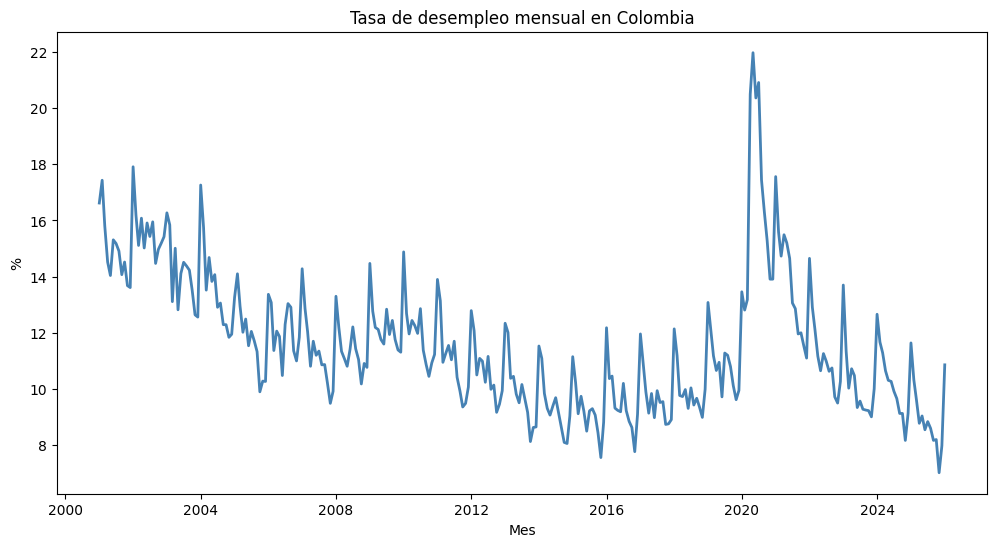

In [126]:
# datos
github_data = "https://raw.githubusercontent.com/fersalme/series-tiempo-econometria/refs/heads/main/data/Mercado%20laboral%20y%20poblaci%C3%B3n.csv"
datos = pd.read_csv(github_data, delimiter=";", decimal=",")
datos.rename(columns={"Periodo(MMM, AAAA)" : "fecha", 
                    "Tasa de desempleo - total nacional" : "tasa_desempleo", 
                    "Tasa de ocupación - total naciona" : "tasa_ocupacion"}, inplace=True)
datos["fecha"] = pd.to_datetime(datos["fecha"])
datos = datos.set_index('fecha')
datos.index = pd.DatetimeIndex(datos.index).to_period('M').to_timestamp()
serie_tasa_desemplo_co = datos.tasa_desempleo

# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_tasa_desemplo_co.index, serie_tasa_desemplo_co, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('%')
plt.title('Tasa de desempleo mensual en Colombia')
plt.show()


In [127]:
# modelos ETS
# Definición de opciones
errores = ["add", "mul"] # A, M
tendencias = [None, "add", "damped"] # N, A, Ad
estacionalidades = [None, "add", "mul"] # N, A, M

ETS_models_dict = dict()

for error in errores:
    for tendencia in tendencias:
        for estacional in estacionalidades:                        
            # Construcción del nombre para la llave del diccionario
            e_label = "A" if error == "add" else "M"
            if tendencia == "damped":
                t_label = "Ad"
            elif tendencia == "add":
                t_label = "A"
            else :
                t_label = "N"
            
            if estacional == "add":
                s_label = "A"
            elif estacional == "mul":
                s_label = "M"
            else:
                s_label = "N"

            nombre_modelo = f"ETS({e_label},{t_label},{s_label})"
            
            es_amortiguada = tendencia == "damped"
            tendencia_ajd = "add" if tendencia == "damped" else tendencia

            # Inicializar el modelo ETS
            model = ETSModel(serie_tasa_desemplo_co, 
                            error=error, trend=tendencia_ajd, 
                            seasonal=estacional, damped_trend=es_amortiguada, seasonal_periods=12, 
                            initialization_method="estimated").fit()
                
            # Guardar en el diccionario
            ETS_models_dict[nombre_modelo] = model


In [128]:
# Mejor modelo
modelos_ETS_aic = pd.DataFrame({
    "Modelos" : list(ETS_models_dict),
    "AIC"  : [m.aic for m in ETS_models_dict.values()] 
}).sort_values("AIC")

# Mejor modelo
modelos_ETS_aic

,Modelos,AIC
10,"ETS(M,N,A)",670.838965
13,"ETS(M,A,A)",674.857439
16,"ETS(M,Ad,A)",676.636161
11,"ETS(M,N,M)",679.892710
14,"ETS(M,A,M)",695.940574
17,"ETS(M,Ad,M)",704.271928
1,"ETS(A,N,A)",745.107107
4,"ETS(A,A,A)",748.861382
7,"ETS(A,Ad,A)",750.966205
2,"ETS(A,N,M)",755.115090


In [129]:
# Imprimir modelo
print("Modelo ETS(M,N,A)\n")
print(ETS_models_dict[modelos_ETS_aic.Modelos.iloc[0]].summary())

Modelo ETS(M,N,A)

                                 ETS Results                                  
Dep. Variable:         tasa_desempleo   No. Observations:                  301
Model:                       ETS(MNA)   Log Likelihood                -319.419
Date:                Mon, 13 Apr 2026   AIC                            670.839
Time:                        16:43:42   BIC                            730.153
Sample:                    01-01-2001   HQIC                           694.574
                         - 01-01-2026   Scale                            0.004
Covariance Type:               approx                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.7812      0.052     15.103      0.000       0.680       0.883
smoothing_seasonal   2.188e-05        nan        nan        nan         nan         n

**Interpretación**

- Error multiplicativo (M): El modelo asume que la variabilidad residual no es constante. Si la tasa de desempleo sube, la incertidumbre también aumenta proporcionalmente. Esto se confirma con la prueba de Heterocedasticidad (H) de 1.83 (p-valor < 0.05), que indica que la varianza de los errores cambia en el tiempo.
- Sin tendencia (N): El modelo no detectó una dirección clara de crecimiento o decrecimiento persistente a largo plazo. Se comporta como un modelo que oscila alrededor de un nivel que cambia localmente.
- Estacionalidad aditiva (A): Los picos y valles mensuales se suman o restan de forma fija (en puntos porcentuales) al nivel, independientemente del nivel de desempleo.

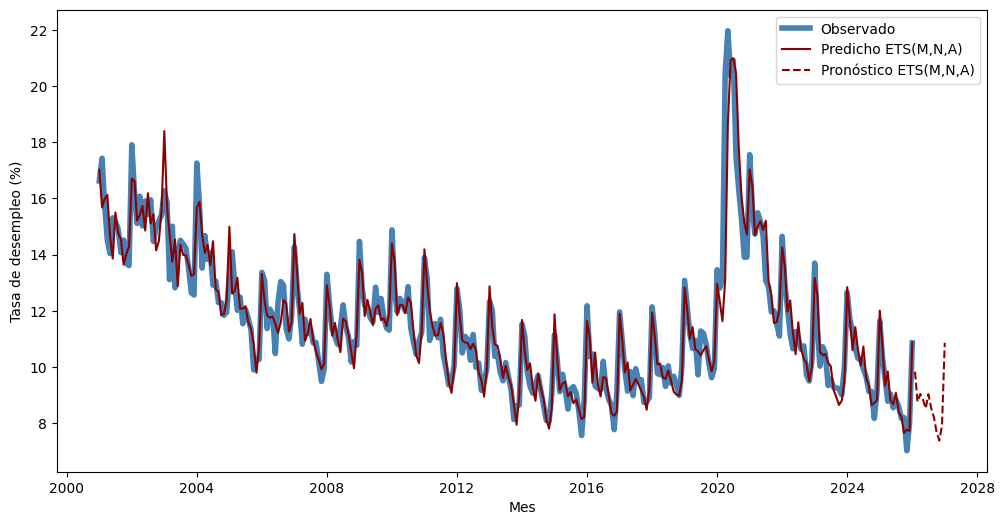

In [130]:
# Pronostico de los proximos 12 meses
t_pronostico = 12
ultimo_dato  = serie_tasa_desemplo_co.index[-1]
anio_pronostico = pd.date_range(start=ultimo_dato + pd.offsets.MonthBegin(1), periods=t_pronostico, freq='MS')

# Obtener valores promedios e intervalos del pronostico
mejor_ETS = ETS_models_dict["ETS(M,N,A)"]
pronostico_ETS = mejor_ETS.forecast(steps=t_pronostico)
pronostico_ETS.index = anio_pronostico 

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_tasa_desemplo_co.index, serie_tasa_desemplo_co, label="Observado", color='steelblue', linewidth=4)
ax.plot(serie_tasa_desemplo_co.index, mejor_ETS.fittedvalues, label="Predicho ETS(M,N,A)", color='darkred')
ax.plot(pronostico_ETS.index, pronostico_ETS, label="Pronóstico ETS(M,N,A)", color='darkred', linestyle='--')
plt.xlabel('Mes')
plt.ylabel("Tasa de desempleo (%)")
ax.legend()
plt.show()

## Regresión armónica dinámica (estacionalidad de largo plazo)

- Cuando existen períodos estacionales largos, a menudo implican múltiples patrones estacionales, por lo que es necesario utilizar un método que gestione este tipo de estacionalidad compleja.

- Si $m$ es el período estacional, entonces los primeros términos de Fourier vienen dados por :

$$
x_{1,t} = \sin\left(\textstyle\frac{2\pi t}{m}\right),
x_{2,t} = \cos\left(\textstyle\frac{2\pi t}{m}\right),
x_{3,t} = \sin\left(\textstyle\frac{4\pi t}{m}\right),
$$

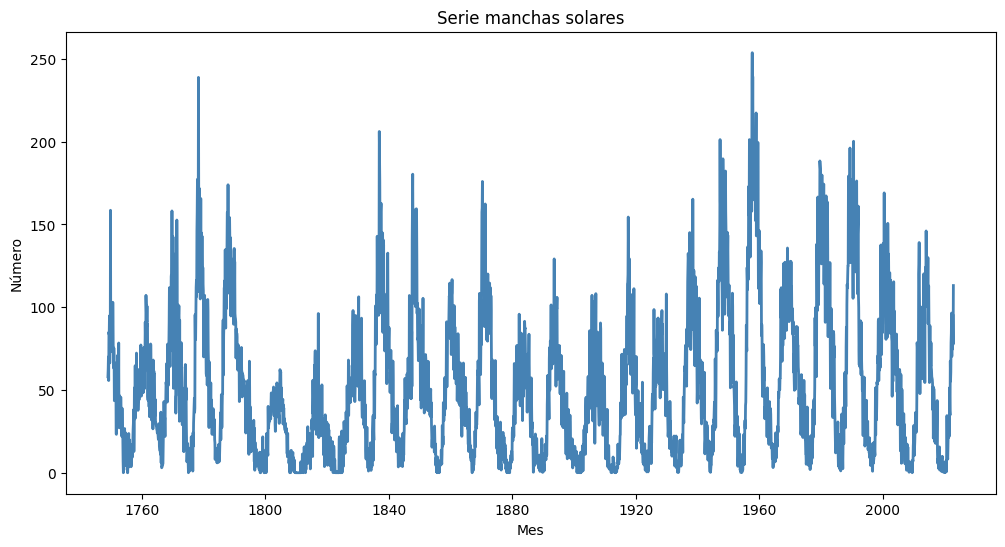

In [144]:
datos_sunsot = "https://raw.githubusercontent.com/STAT-JET-ASU/Datasets/master/Instructor/sunspots.csv"
datos = pd.read_csv(datos_sunsot)
datos["fecha"] = pd.to_datetime(datos["year"].astype(str) + "-" + 
                               datos["month"].astype(str) + "-01")
datos = datos.set_index('fecha')
datos.index = pd.DatetimeIndex(datos.index).to_period('M').to_timestamp()
serie_sunspot = datos.average

# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_sunspot.index, serie_sunspot, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Número')
plt.title('Serie manchas solares')
plt.show()

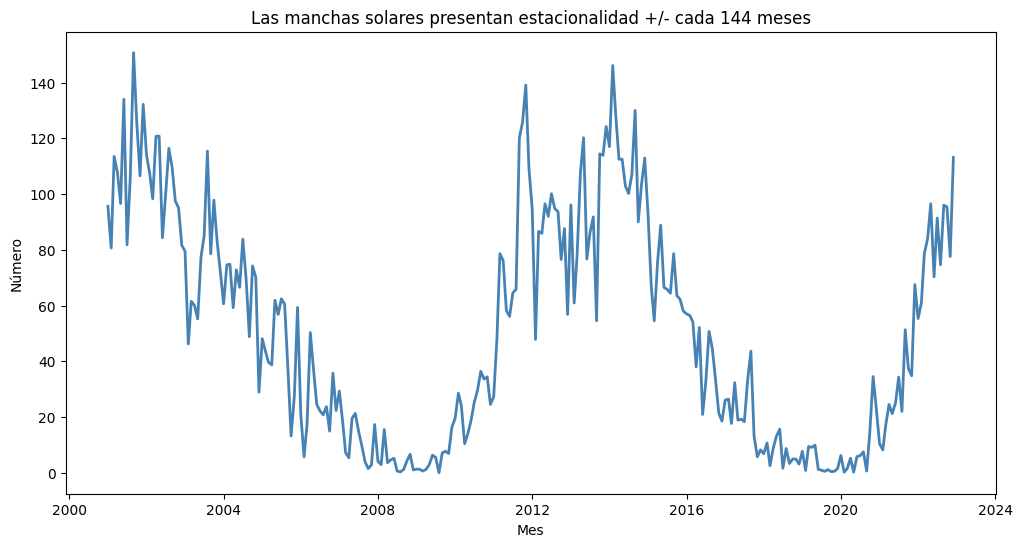

In [168]:
# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_sunspot.index[serie_sunspot.index >= "2000-12-31"], serie_sunspot[serie_sunspot.index >= "2000-12-31"], color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Número')
plt.title('Las manchas solares presentan estacionalidad +/- cada 144 meses')
plt.show()


In [230]:
# modelos 
terminos_fourier = DeterministicProcess(serie_sunspot.index,
                                        constant=True,
                                        period=140, # Ciclos estacionales toman más de un año
                                        fourier=2) # incluir terminos de fourier que forman una onda a mayor K mayor ajuste

# crear los datos
exog_fourier = terminos_fourier.in_sample()
exog_fourier.head()

,const,"sin(1,140)","cos(1,140)","sin(2,140)","cos(2,140)"
fecha,,,,,
1749-01-01,1.0,0.000000,1.000000,0.000000,1.000000
1749-02-01,1.0,0.044865,0.998993,0.089639,0.995974
1749-03-01,1.0,0.089639,0.995974,0.178557,0.983930
1749-04-01,1.0,0.134233,0.990950,0.266037,0.963963
1749-05-01,1.0,0.178557,0.983930,0.351375,0.936235


In [231]:
# modelo
modelo_armonico = SARIMAX(serie_sunspot, exog=exog_fourier, order=(0, 0, 0), trend='n').fit()
print(modelo_armonico.summary())

                               SARIMAX Results                                
Dep. Variable:                average   No. Observations:                 3288
Model:                        SARIMAX   Log Likelihood              -17000.678
Date:                Mon, 13 Apr 2026   AIC                          34013.356
Time:                        18:13:55   BIC                          34049.944
Sample:                    01-01-1749   HQIC                         34026.455
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.4403      0.968     54.174      0.000      50.543      54.338
sin(1,140)   -13.8200      1.132    -12.210      0.000     -16.038     -11.602
cos(1,140)    -7.6061      1.047     -7.266      0.0

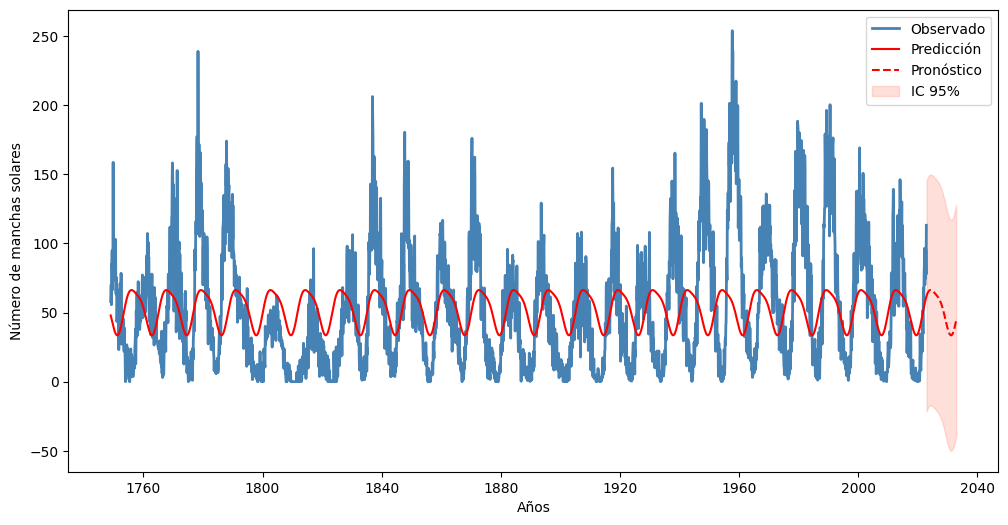

In [232]:
# Pronostico los proximos 10 años = 12 meses * 10 años  = 120
t_pronostico = 120
ultimo_dato  = serie_sunspot.index[-1]
anio_pronostico = pd.date_range(start=ultimo_dato + pd.offsets.MonthBegin(1), periods=t_pronostico, freq='MS')

# Obtener valores promedios e intervalos del pronostico
exog_futuro = terminos_fourier.out_of_sample(steps=t_pronostico)
pronostico = modelo_armonico.get_forecast(steps=t_pronostico, exog=exog_futuro)
pred_mean = pronostico.predicted_mean
pred_ci = pronostico.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_sunspot.index, serie_sunspot, label="Observado", color='steelblue', linewidth=2)
ax.plot(serie_sunspot.index, modelo_armonico.fittedvalues, label="Predicción", color='red')
ax.plot(pred_mean.index, pred_mean, label="Pronóstico", color='red', linestyle='--')
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Años')
ax.set_ylabel('Número de manchas solares')
ax.legend()
plt.show()